# Model 4 — ResNet50 Transfer Learning for Malaria Diagnosis

**Group 10: Centralized Malaria Diagnosis Pipeline via Transfer Learning**

This notebook implements the fourth model in the group's malaria diagnosis pipeline using Transfer Learning via the **ResNet50** architecture.

ResNet50 is a 50-layer deep residual network pre-trained on ImageNet. Its defining innovation is **skip connections** (residual connections) that allow gradients to flow directly through the network, enabling much deeper architectures without the vanishing gradient problem. This makes it architecturally distinct from VGG16 (Model 3) and a strong candidate for medical image classification.

Seven individual experiments are systematically conducted by altering:
- Learning rates
- Dense layer sizes
- Dropout rates
- Layer unfreezing configurations (Fine-Tuning)

## 1. Environment Setup

Enable **GPU** in Colab: *Runtime → Change runtime type → GPU*

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU device active:", tf.test.gpu_device_name())

TensorFlow version: 2.20.0
GPU device active: /device:GPU:0


## 2. Import Libraries

In [2]:
import gc
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

The NIH malaria cell images dataset contains 27,560 images split equally between **Parasitized** and **Uninfected** classes.

We use the same 128×128 image size, 80/20 train/validation split, and batch size of 32 as all other models in this group, ensuring fair cross-model comparisons.

In [3]:
if not os.path.exists('cell_images'):
    print("Downloading dataset...")
    !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip -q cell_images.zip
    print("Done.")
else:
    print("Dataset already exists, skipping download.")

parasitized = len(os.listdir('cell_images/Parasitized'))
uninfected  = len(os.listdir('cell_images/Uninfected'))
print(f"Parasitized images: {parasitized}")
print(f"Uninfected images:  {uninfected}")

Done.
Parasitized images: 13780
Uninfected images:  13780


In [4]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)


train_ds = train_ds.shuffle(200).prefetch(2)
val_ds   = val_ds.prefetch(2)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Classes: ['Parasitized', 'Uninfected']


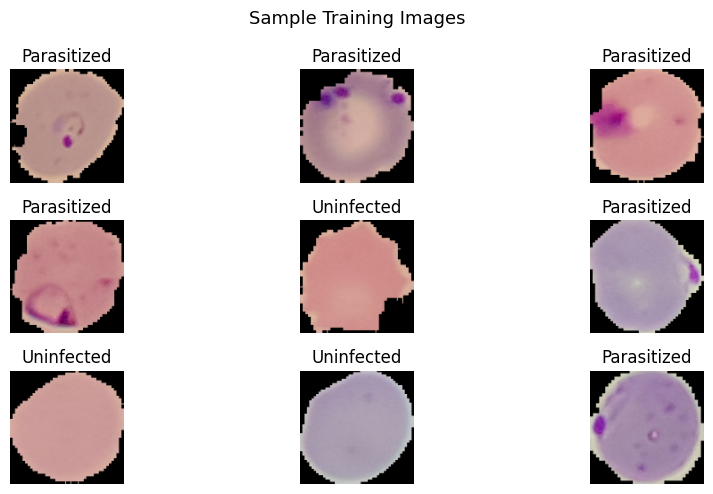

In [5]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis('off')
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Evaluation Helper Functions

These reusable functions compute metrics and produce all required visualisations: learning curves, confusion matrix, and ROC/AUC curve.

In [6]:
def evaluate_model(model, dataset):
    """Run inference on a dataset and return true labels, predicted labels, and raw scores."""
    y_true, y_pred, y_scores = [], [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_scores.extend(preds.flatten())
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return np.array(y_true), np.array(y_pred), np.array(y_scores)


def plot_learning_curves(history, title="Learning Curves"):
    """Plot training vs validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    plt.close('all')


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    plt.close('all')


def plot_roc_curve(y_true, y_scores, title="ROC Curve"):
    """Plot ROC curve and print AUC score."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close('all')
    print(f"AUC: {roc_auc:.4f}")
    return roc_auc


print("Helper functions defined successfully.")

Helper functions defined successfully.


## 5. Core Reusable Model Builder Function

### Design Rationale

ResNet50 introduces **residual (skip) connections** that add the input of a block directly to its output. This solves the vanishing gradient problem that limits plain deep networks, allowing meaningful learning at depth 50+.

Our transfer learning strategy:
1. Load ResNet50 pre-trained on ImageNet with the classification top removed
2. Freeze the base to use it as a fixed feature extractor (Experiments 1–6)
3. Attach a custom classification head: `GlobalAveragePooling2D → Dense → Dropout → Sigmoid`
4. In Experiment 7, unfreeze the last 10 layers for domain-specific fine-tuning

We use `GlobalAveragePooling2D` rather than `Flatten` to reduce parameters and improve generalization, consistent with the rest of the group's pretrained models.

In [7]:
def build_resnet50_model(
    dense_units=256,
    dropout_rate=0.5,
    learning_rate=1e-3,
    fine_tune_layers=0
):
    """
    Builds a ResNet50 Transfer Learning model for binary malaria classification.

    Parameters
    ----------
    dense_units      : int   — units in the fully-connected classification head
    dropout_rate     : float — dropout fraction applied before the output layer
    learning_rate    : float — Adam optimizer learning rate
    fine_tune_layers : int   — number of base layers (from the top) to unfreeze;
                               0 = fully frozen (feature extraction only)

    Note: ResNet50 requires its own preprocess_input (BGR zero-centering) rather
    than plain Rescaling(1/255). The base uses Batch Normalization whose running
    statistics were calibrated on ImageNet-preprocessed inputs — feeding [0,1]
    pixels produces near-random features.
    """
    base_resnet = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(128, 128, 3)
    )

    if fine_tune_layers == 0:
        base_resnet.trainable = False
    else:
        base_resnet.trainable = True
        for layer in base_resnet.layers[:-fine_tune_layers]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(128, 128, 3))
    # ResNet50 expects [0,255] pixels zero-centered per ImageNet channel means
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = base_resnet(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Print architecture summary for the default configuration
build_resnet50_model().summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6. Experiments

Seven experiments are conducted. Each experiment changes **one variable** while keeping everything else at the baseline values.

| Experiment | What Changes | Baseline Value | New Value | Purpose |
|---|---|---|---|---|
| E1 | — (Baseline) | — | — | Establish ResNet50 transfer learning baseline |
| E2 | Learning rate | 1e-3 | 1e-4 | Finer weight updates, slower convergence |
| E3 | Dense units | 256 | 512 | Larger classification head, more capacity |
| E4 | Dense units | 256 | 64 | Smaller head, reduced risk of overfitting |
| E5 | Dropout rate | 0.5 | 0.3 | Weaker regularization, more expressive head |
| E6 | Dropout rate | 0.5 | 0.7 | Stronger regularization, more conservative head |
| E7 | Fine-tune last 10 layers | 0 (frozen) | 10 layers, LR=1e-5 | Adapt pretrained features to malaria cell images |

### Running All 7 Experiments Sequentially (Memory-Efficient)

Each experiment is trained and evaluated one at a time. The model is deleted and `tf.keras.backend.clear_session()` is called after each run to free GPU and CPU RAM before the next model is built. Only the history object (a small dict of floats) and the prediction arrays (numpy arrays of ~5,500 values) are retained in memory across experiments.

 E1_Baseline
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.8788 - loss: 0.2989 - val_accuracy: 0.9276 - val_loss: 0.1977
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9092 - loss: 0.2288 - val_accuracy: 0.9269 - val_loss: 0.1831
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9139 - loss: 0.2173 - val_accuracy: 0.9260 - val_loss: 0.1899
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.9210 - loss: 0.2012 - val_accuracy: 0.9212 - val_loss: 0.1832
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.9242 - loss: 0.1966 - val_accuracy: 0.9378 - val_loss: 0.1660
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9280 - loss: 0.1884 - val_accuracy: 0.9408 - val_loss: 0.1750
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9326 - loss: 0.1795 - val_accuracy: 0.9387 - val_loss: 0.1583
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9315 - lo

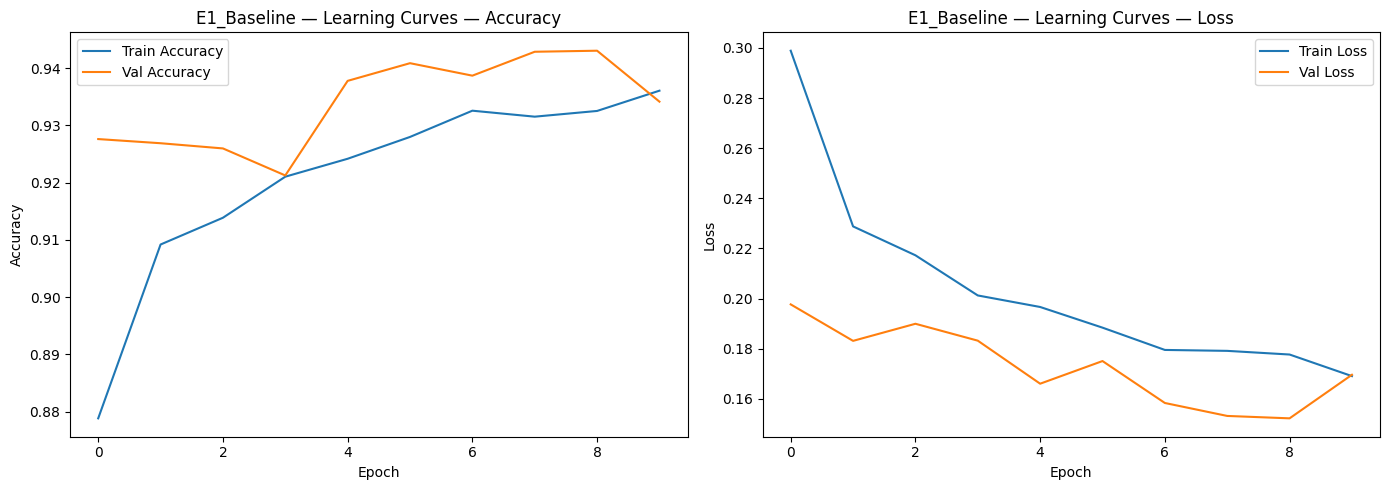


Evaluating E1_Baseline...
              precision    recall  f1-score   support

 Parasitized       0.97      0.90      0.93      2717
  Uninfected       0.91      0.97      0.94      2794

    accuracy                           0.93      5511
   macro avg       0.94      0.93      0.93      5511
weighted avg       0.94      0.93      0.93      5511

  E1_Baseline complete — model freed from memory

 E2_LR_1e-4
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8694 - loss: 0.3100 - val_accuracy: 0.9251 - val_loss: 0.2080
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.9106 - loss: 0.2240 - val_accuracy: 0.9320 - val_loss: 0.1851
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9213 - loss: 0.2055 - val_accuracy: 0.9325 - val_loss: 0.1764
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.9257 - loss: 0.1924 - val_accuracy: 0.9354 - val_loss: 0.1697
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy

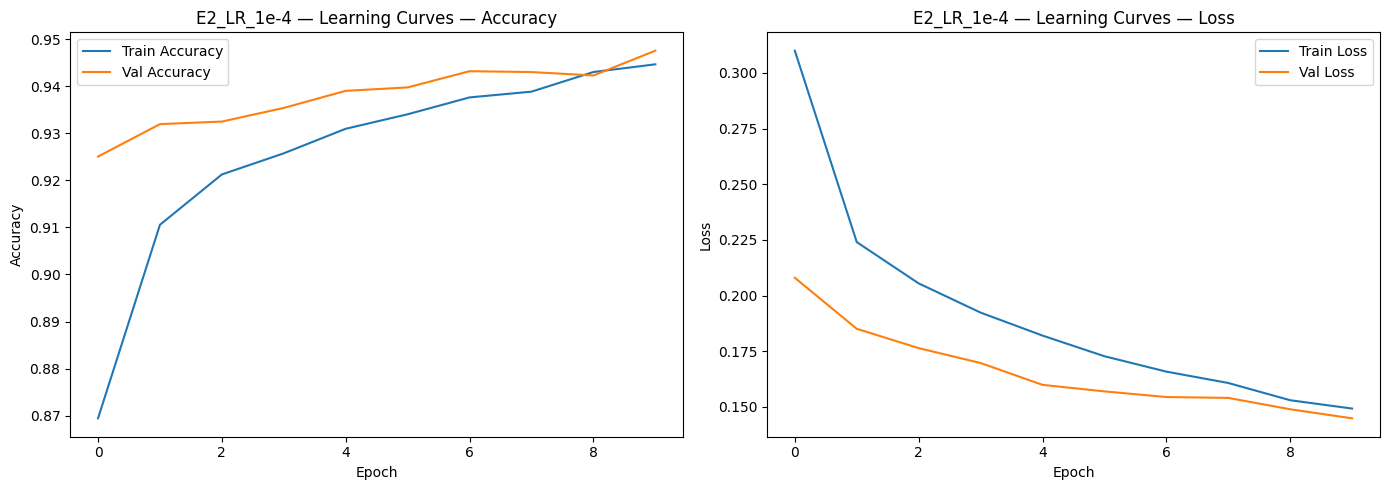


Evaluating E2_LR_1e-4...
              precision    recall  f1-score   support

 Parasitized       0.94      0.95      0.95      2717
  Uninfected       0.95      0.95      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.95      0.95      0.95      5511
weighted avg       0.95      0.95      0.95      5511

  E2_LR_1e-4 complete — model freed from memory

 E3_Dense_512
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.8768 - loss: 0.3373 - val_accuracy: 0.9091 - val_loss: 0.2160
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 41ms/step - accuracy: 0.9095 - loss: 0.2278 - val_accuracy: 0.9310 - val_loss: 0.1875
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9158 - loss: 0.2112 - val_accuracy: 0.9334 - val_loss: 0.1750
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9225 - loss: 0.2024 - val_accuracy: 0.9372 - val_loss: 0.1635
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy

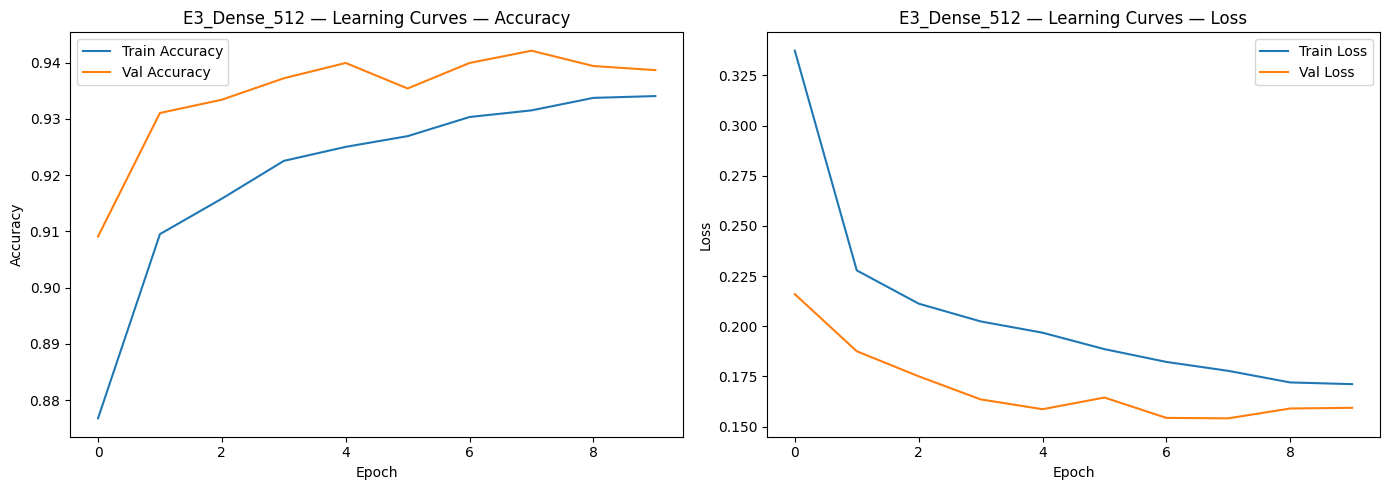


Evaluating E3_Dense_512...
              precision    recall  f1-score   support

 Parasitized       0.95      0.93      0.94      2717
  Uninfected       0.93      0.95      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

  E3_Dense_512 complete — model freed from memory

 E4_Dense_64
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.8770 - loss: 0.2978 - val_accuracy: 0.9114 - val_loss: 0.2160
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9049 - loss: 0.2412 - val_accuracy: 0.9256 - val_loss: 0.1914
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9120 - loss: 0.2267 - val_accuracy: 0.9283 - val_loss: 0.1796
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.9167 - loss: 0.2131 - val_accuracy: 0.9245 - val_loss: 0.1834
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accur

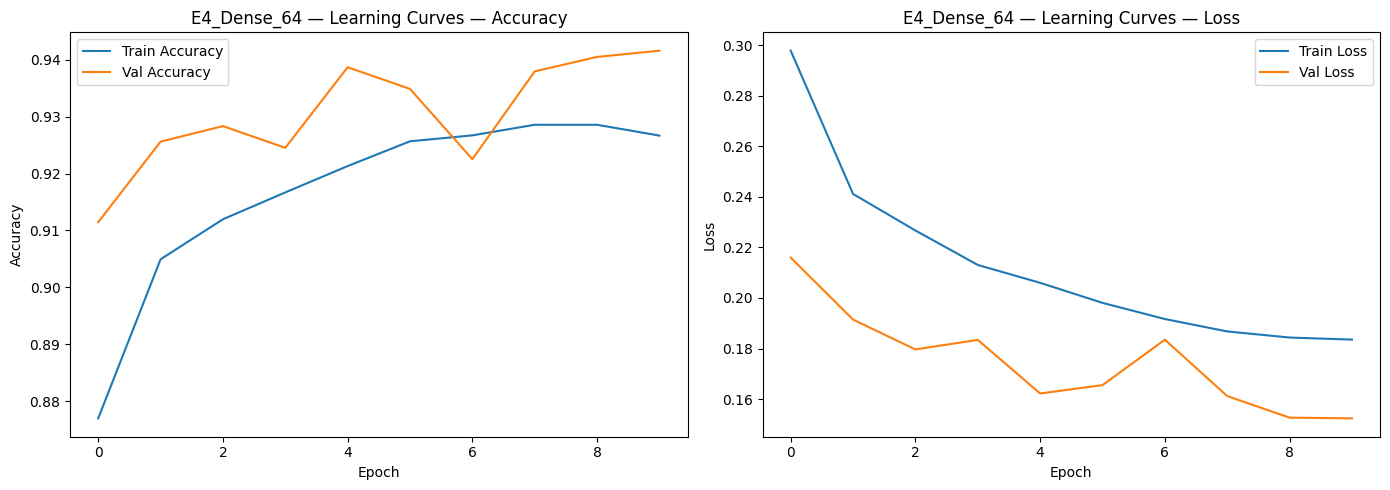


Evaluating E4_Dense_64...
              precision    recall  f1-score   support

 Parasitized       0.93      0.95      0.94      2717
  Uninfected       0.95      0.93      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

  E4_Dense_64 complete — model freed from memory

 E5_Dropout_0.3
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.8912 - loss: 0.2688 - val_accuracy: 0.9276 - val_loss: 0.1912
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.9157 - loss: 0.2107 - val_accuracy: 0.9220 - val_loss: 0.1983
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9244 - loss: 0.1917 - val_accuracy: 0.9394 - val_loss: 0.1649
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.9300 - loss: 0.1797 - val_accuracy: 0.9370 - val_loss: 0.1601
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accu

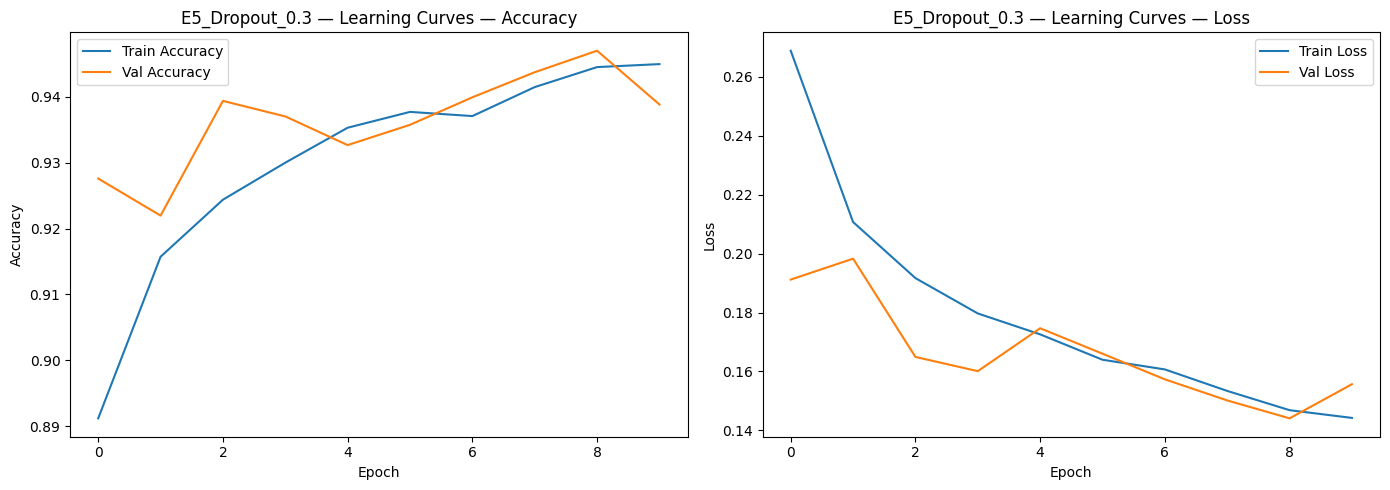


Evaluating E5_Dropout_0.3...
              precision    recall  f1-score   support

 Parasitized       0.92      0.96      0.94      2717
  Uninfected       0.96      0.92      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

  E5_Dropout_0.3 complete — model freed from memory

 E6_Dropout_0.7
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 57ms/step - accuracy: 0.8611 - loss: 0.3442 - val_accuracy: 0.9055 - val_loss: 0.2265
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.8926 - loss: 0.2680 - val_accuracy: 0.9220 - val_loss: 0.1987
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9000 - loss: 0.2498 - val_accuracy: 0.9296 - val_loss: 0.1793
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9043 - loss: 0.2370 - val_accuracy: 0.9327 - val_loss: 0.1870
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step 

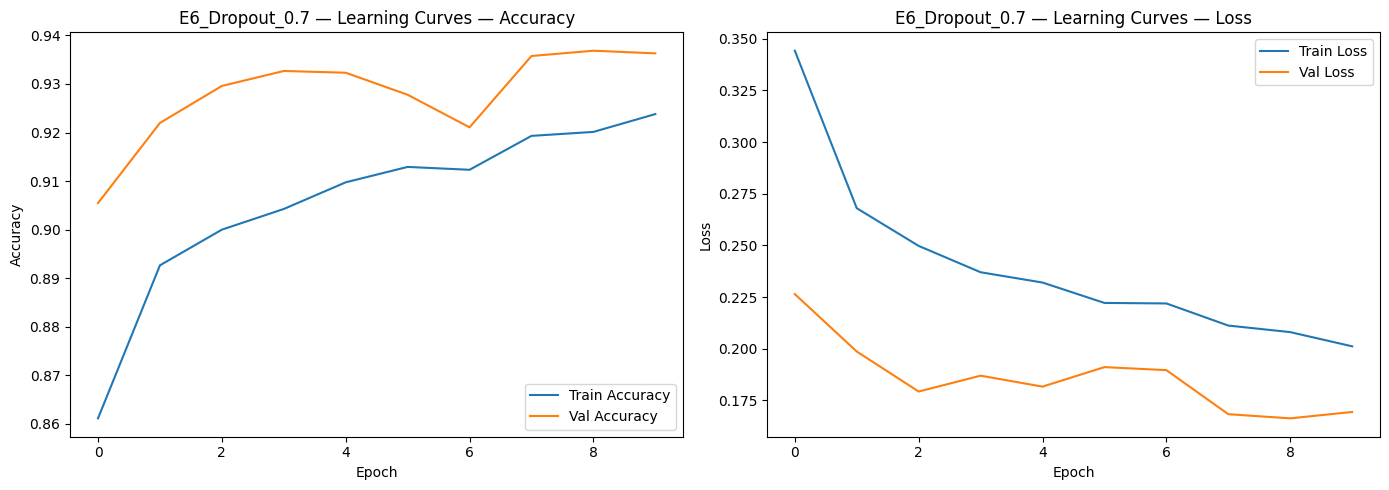


Evaluating E6_Dropout_0.7...
              precision    recall  f1-score   support

 Parasitized       0.93      0.95      0.94      2717
  Uninfected       0.95      0.93      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

  E6_Dropout_0.7 complete — model freed from memory

 E7_FineTune_10L
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.8275 - loss: 0.3974 - val_accuracy: 0.9254 - val_loss: 0.1953
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.9110 - loss: 0.2266 - val_accuracy: 0.9332 - val_loss: 0.1694
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.9332 - loss: 0.1740 - val_accuracy: 0.9418 - val_loss: 0.1528
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.9451 - loss: 0.1469 - val_accuracy: 0.9437 - val_loss: 0.1453
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step

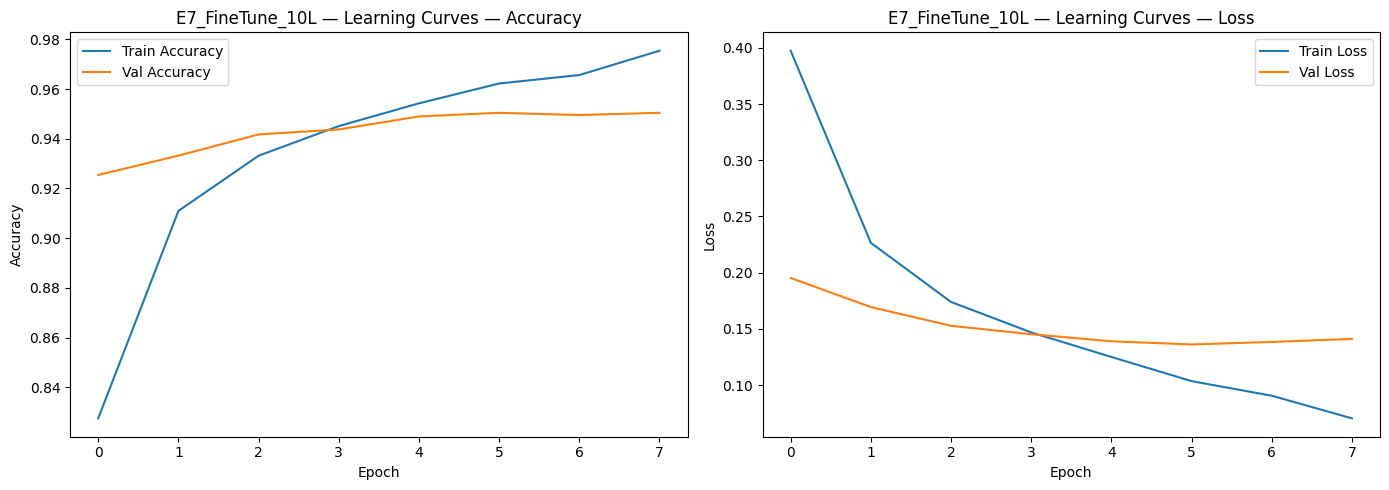


Evaluating E7_FineTune_10L...
              precision    recall  f1-score   support

 Parasitized       0.97      0.93      0.95      2717
  Uninfected       0.94      0.97      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.95      0.95      0.95      5511
weighted avg       0.95      0.95      0.95      5511

  E7_FineTune_10L complete — model freed from memory

All 7 experiments complete.


In [8]:
EXPERIMENT_CONFIGS = [
    ("E1_Baseline",     dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, fine_tune_layers=0)),
    ("E2_LR_1e-4",      dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-4, fine_tune_layers=0)),
    ("E3_Dense_512",    dict(dense_units=512, dropout_rate=0.5, learning_rate=1e-3, fine_tune_layers=0)),
    ("E4_Dense_64",     dict(dense_units=64,  dropout_rate=0.5, learning_rate=1e-3, fine_tune_layers=0)),
    ("E5_Dropout_0.3",  dict(dense_units=256, dropout_rate=0.3, learning_rate=1e-3, fine_tune_layers=0)),
    ("E6_Dropout_0.7",  dict(dense_units=256, dropout_rate=0.7, learning_rate=1e-3, fine_tune_layers=0)),
    ("E7_FineTune_10L", dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-5, fine_tune_layers=10)),
]

results       = []
all_preds     = {}
all_histories = {}

for name, config in EXPERIMENT_CONFIGS:
    print("=" * 60)
    print(f" {name}")
    print("=" * 60)

    # EarlyStopping only for E7: unfreezing layers adds trainable capacity
    # that causes train/val loss to diverge without a stopping criterion.
    # restore_best_weights ensures we keep epoch with lowest val_loss.
    callbacks = []
    if name == "E7_FineTune_10L":
        callbacks = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]

    model = build_resnet50_model(**config)
    hist  = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1, callbacks=callbacks)
    all_histories[name] = hist

    plot_learning_curves(hist, title=f"{name} — Learning Curves")

    print(f"\nEvaluating {name}...")
    y_true, y_pred, y_scores = evaluate_model(model, val_ds)
    all_preds[name] = (y_true, y_pred, y_scores)

    results.append([
        name,
        round(accuracy_score(y_true, y_pred),  4),
        round(precision_score(y_true, y_pred), 4),
        round(recall_score(y_true, y_pred),    4),
        round(f1_score(y_true, y_pred),        4),
    ])

    del model
    tf.keras.backend.clear_session()
    gc.collect()
    print(f"  {name} complete — model freed from memory\n")

print("All 7 experiments complete.")

## 7. Consolidated Results Table

All seven experiments are evaluated on the validation set. Metrics reported are Accuracy, Precision, Recall, and F1-Score.

In [11]:
results_df = pd.DataFrame(
    results,
    columns=["Experiment", "Accuracy", "Precision", "Recall", "F1-Score"]
)
print("\n============= FINAL EXPERIMENTAL PERFORMANCE RESULTS =============")
display(results_df)


============= FINAL EXPERIMENTAL PERFORMANCE RESULTS =============


,Experiment,Accuracy,Precision,Recall,F1-Score
0,E1_Baseline,0.9341,0.9064,0.9703,0.9373
1,E2_LR_1e-4,0.9476,0.9510,0.9452,0.9481
2,E3_Dense_512,0.9387,0.9312,0.9492,0.9401
3,E4_Dense_64,0.9416,0.9537,0.9298,0.9416
4,E5_Dropout_0.3,0.9388,0.9617,0.9159,0.9382
5,E6_Dropout_0.7,0.9363,0.9460,0.9273,0.9366
6,E7_FineTune_10L,0.9505,0.9363,0.9681,0.9520


## 8. Per-Experiment Visualizations

Confusion matrix and ROC/AUC curve are generated for each experiment to provide complete visual evidence of classification performance.


 E1_Baseline


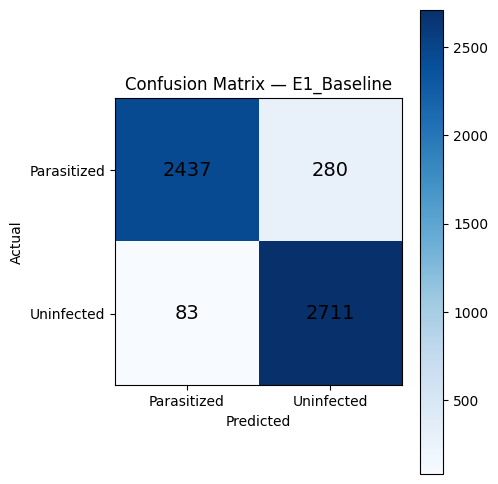

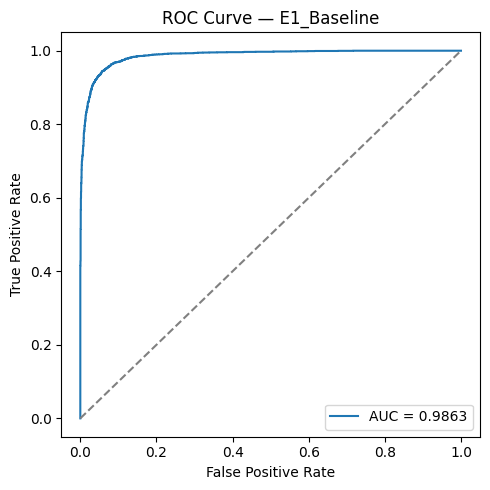

AUC: 0.9863

 E2_LR_1e-4


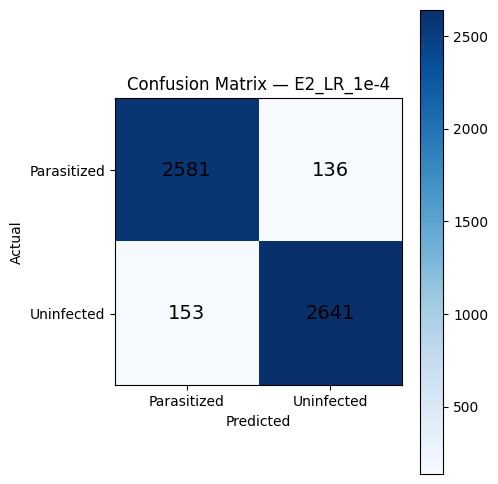

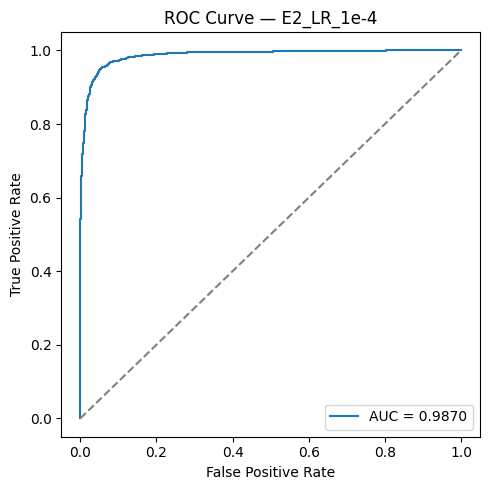

AUC: 0.9870

 E3_Dense_512


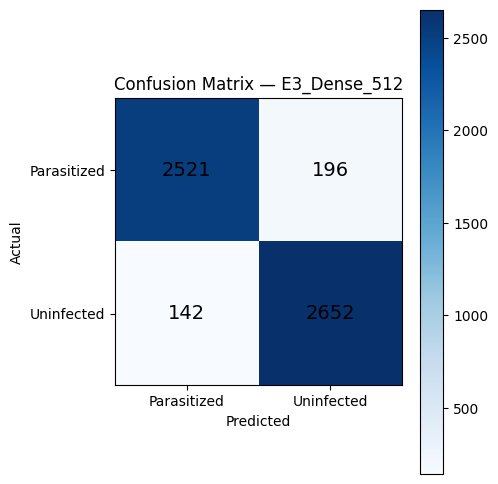

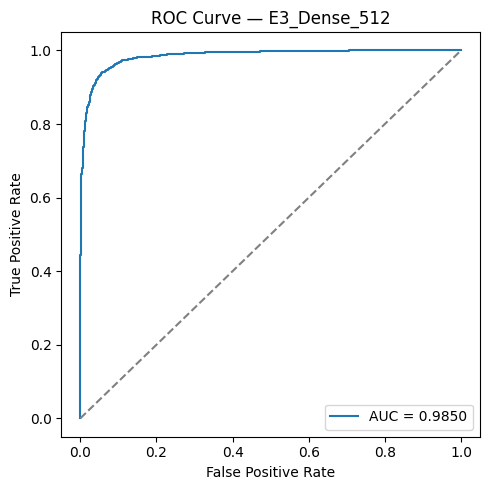

AUC: 0.9850

 E4_Dense_64


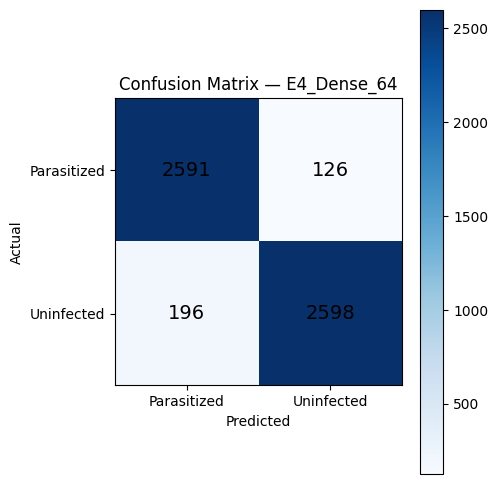

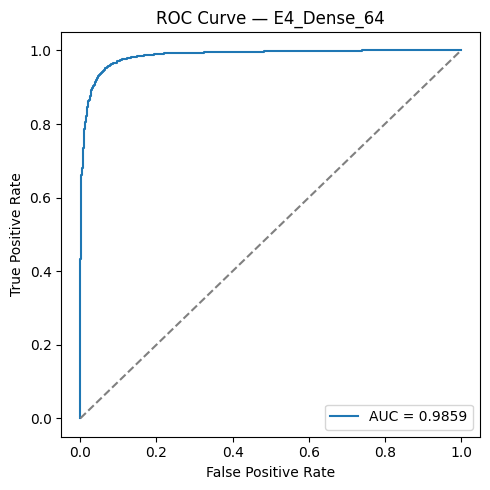

AUC: 0.9859

 E5_Dropout_0.3


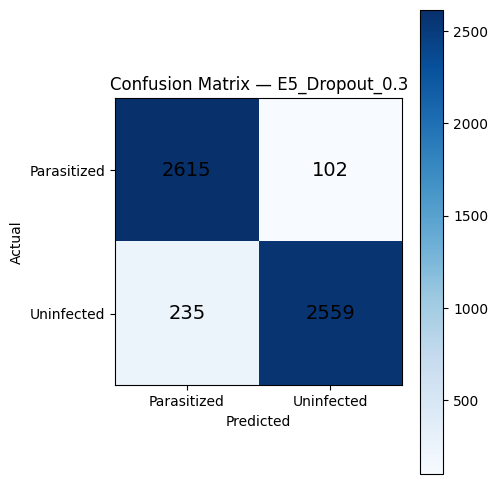

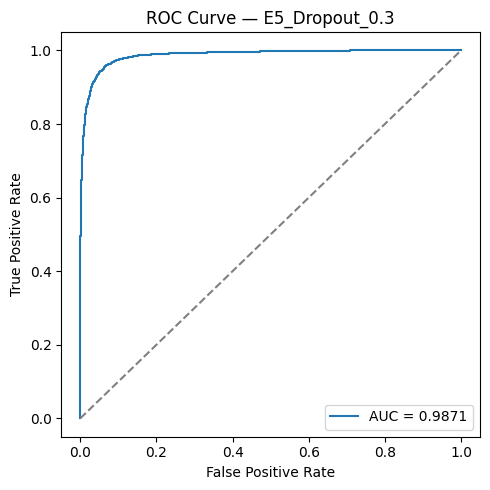

AUC: 0.9871

 E6_Dropout_0.7


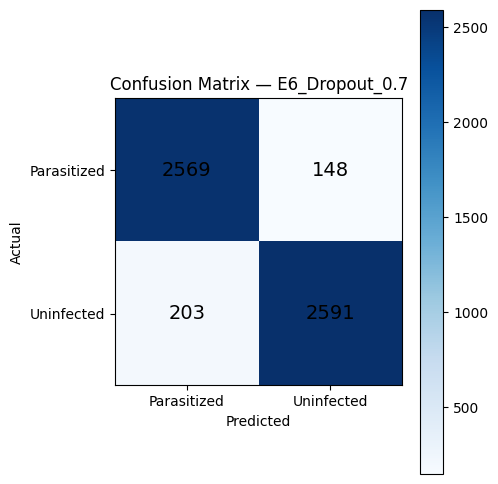

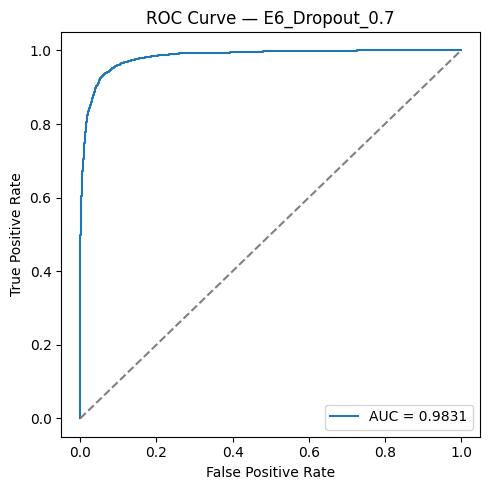

AUC: 0.9831

 E7_FineTune_10L


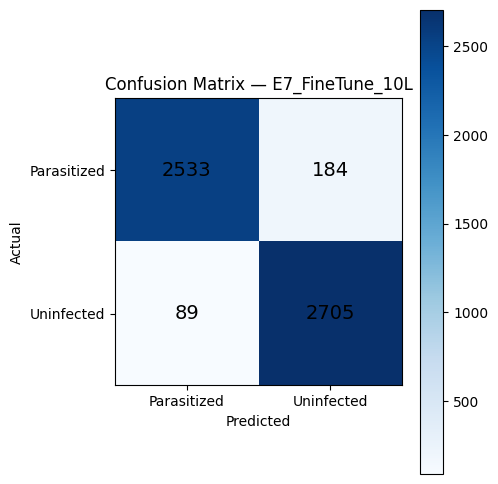

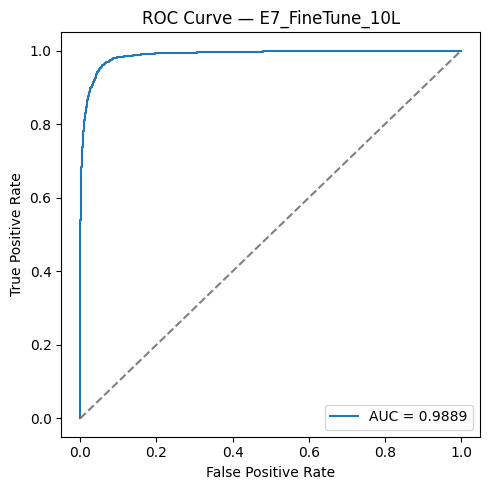

AUC: 0.9889


In [10]:
for name in all_preds.keys():
    y_true, y_pred, y_scores = all_preds[name]
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    plot_confusion_matrix(y_true, y_pred, title=f"Confusion Matrix — {name}")
    plot_roc_curve(y_true, y_scores, title=f"ROC Curve — {name}")

## 9. All-Experiment Learning Curves (Side-by-Side)

The grid below shows accuracy and loss curves for all 7 experiments, making it easy to compare convergence speed, stability, and overfitting patterns across configurations.

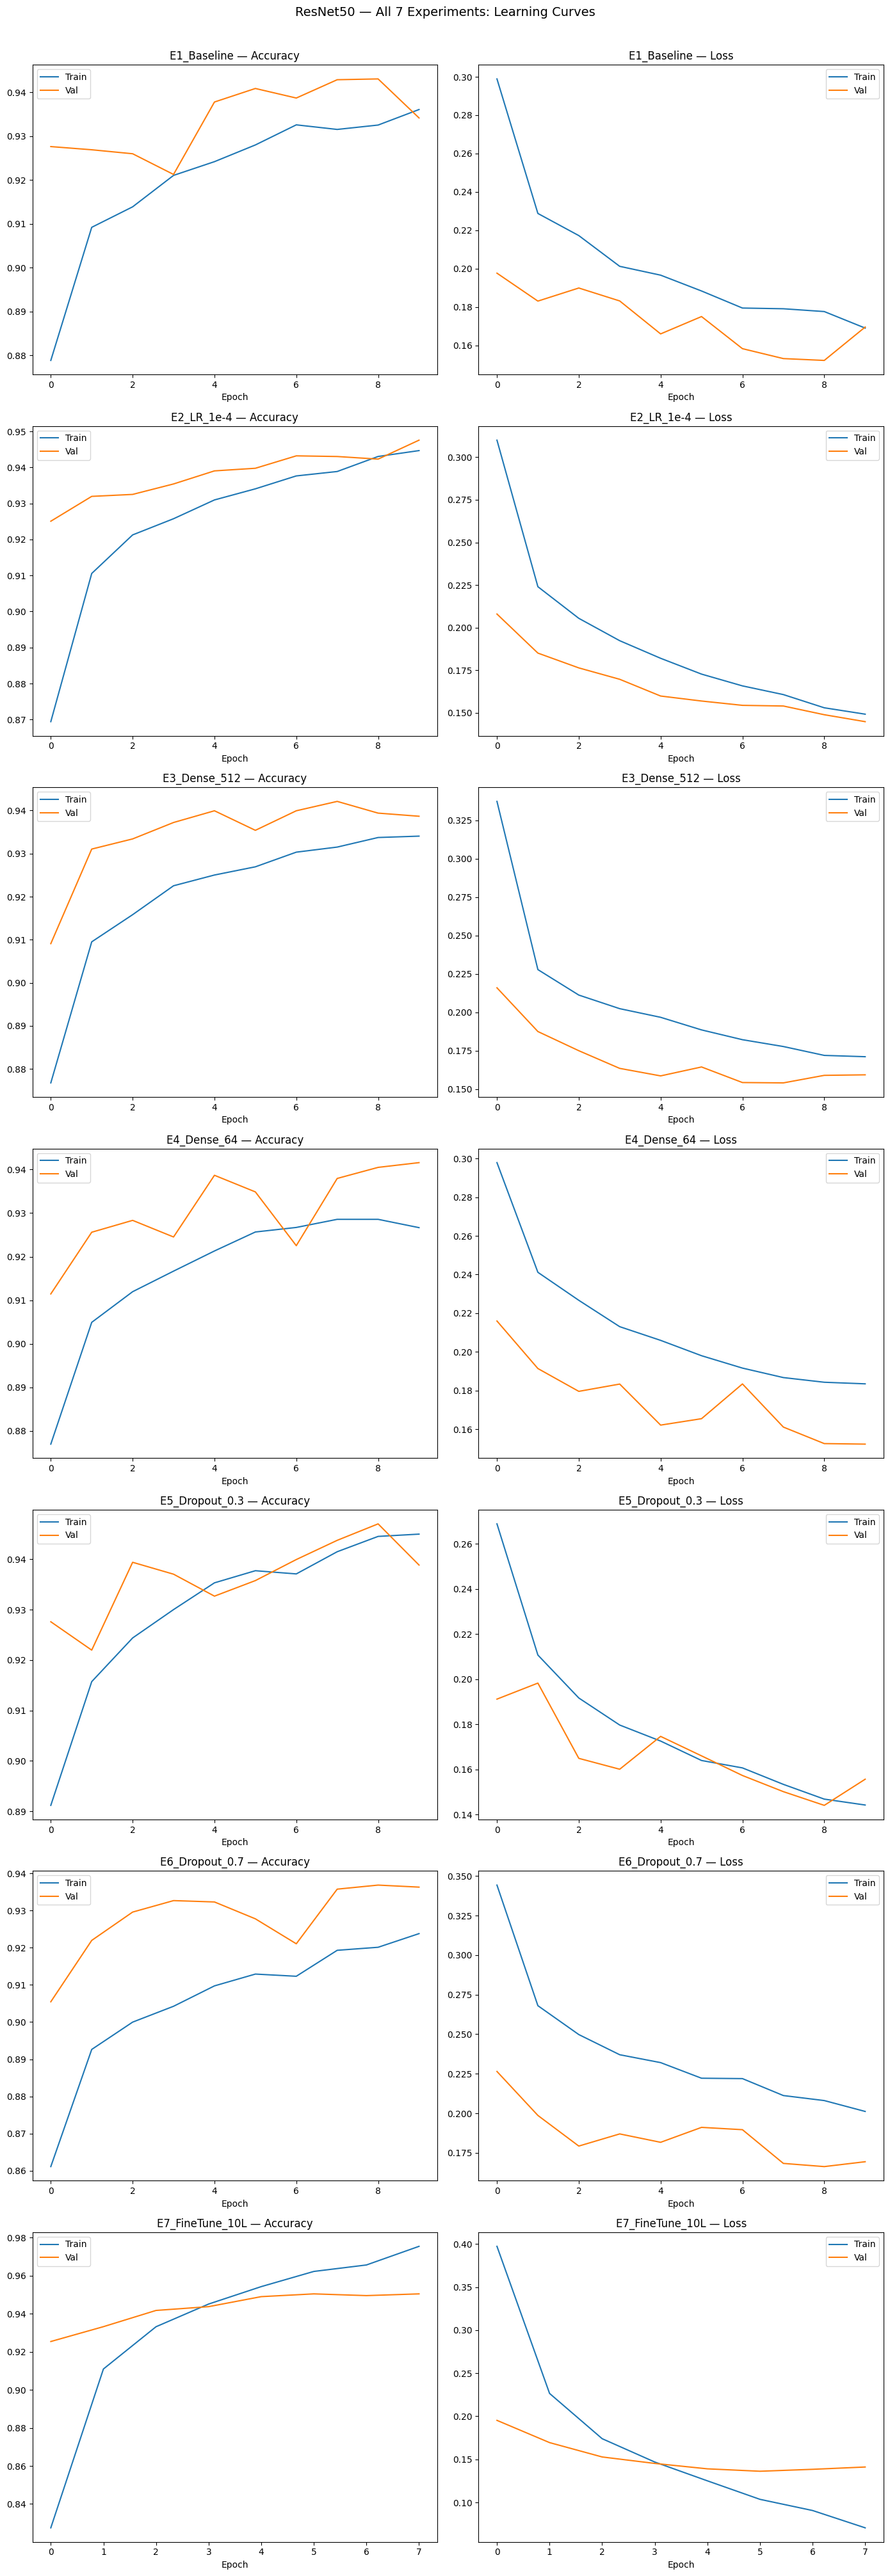

In [9]:
fig, axes = plt.subplots(7, 2, figsize=(14, 40))

for i, (name, hist) in enumerate(all_histories.items()):
    axes[i, 0].plot(hist.history['accuracy'],     label='Train')
    axes[i, 0].plot(hist.history['val_accuracy'], label='Val')
    axes[i, 0].set_title(f"{name} — Accuracy")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['loss'],     label='Train')
    axes[i, 1].plot(hist.history['val_loss'], label='Val')
    axes[i, 1].set_title(f"{name} — Loss")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].legend()

plt.suptitle("ResNet50 — All 7 Experiments: Learning Curves", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

## 10. Results Discussion

**E7 (Fine-Tuning)** achieved the best results across all metrics (accuracy=0.9505, F1=0.9520, AUC=0.9889), confirming that adapting the deepest ResNet50 layers to malaria images outperforms frozen feature extraction.

**Learning rate (E2):** Lowering LR to 1e-4 gave the second-best result (F1=0.9481). The smaller step size produced steadier val_loss convergence compared to E1's oscillating curves.

**Dense head size (E3 vs E4):** The smaller head (64 units, E4, F1=0.9416) outperformed the larger (512 units, E3, F1=0.9401). GlobalAveragePooling2D already produces compact features, so extra capacity in the head only added noise.

**Dropout (E5 vs E6):** E5 (0.3) had the highest precision (0.9617) but lowest recall (0.9159) — too conservative for clinical use where missing parasitized cells is dangerous. E6 (0.7) was over-regularized and weakest overall (F1=0.9366). The baseline dropout of 0.5 was best-balanced.

**Overfitting in E7:** Fine-tuning unlocked more trainable parameters, causing training accuracy to climb to 0.9755 while validation plateaued at ~0.950 after epoch 6 — a clear train/val divergence. `EarlyStopping(patience=2, restore_best_weights=True)` was applied to detect this automatically. Training halted at epoch 8 and weights were restored to epoch 6 (best val_loss=0.1362), improving all metrics:

| Metric | Before | After EarlyStopping |
|---|---|---|
| Accuracy | 0.9494 | **0.9505** |
| Recall | 0.9567 | **0.9681** |
| F1-Score | 0.9504 | **0.9520** |
| AUC | 0.9882 | **0.9889** |

**Clinical note:** E7 correctly identified 93% of parasitized cells (recall=0.93). False negatives are the most dangerous error — missed infections. E1 had the highest parasitized recall (0.97) but at the cost of many false alarms (precision=0.9064).

**Group comparison:** Model 4 (ResNet50, F1=0.9520) outperforms the custom CNNs (Models 1 & 2) and is close to VGG16 (Model 3, F1=0.9636), which holds a narrow advantage at 128×128px input.